In [1]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def plot_execution_time(json_data):
    dfj_times, mtz_times = {}, {}

    for full_run in json_data.values():
        for execution in full_run:
            n = execution["n"]

            if n not in dfj_times:
                dfj_times[n] = []
                mtz_times[n] = []

            dfj_times[n].append(execution["dfj_time_ms"])
            mtz_times[n].append(execution["mtz_time_ms"])   

    x_values = sorted(dfj_times.keys())

    dfj_avg = [sum(dfj_times[n]) / len(dfj_times[n]) for n in x_values]
    mtz_avg = [sum(mtz_times[n]) / len(mtz_times[n]) for n in x_values]
    print(dfj_avg)
    print(mtz_avg)

    plt.figure(figsize=(10, 6))

    plt.plot(x_values, dfj_avg, marker="o", label="DFJ average")
    plt.plot(x_values, mtz_avg, marker="o", label="MTZ average")

    plt.xlabel("Number of nodes (n)")
    plt.ylabel("Average execution time (ms)")
    plt.title("Average Execution Time Comparison: DFJ vs MTZ")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

[20.02985799976159, 58.490499000072305, 230.8302149985684, 325.2717039988056, 767.2259609990215, 939.0142359984748, 1524.0109350001148, 2203.5631170005217, 3240.2404989993015, 5806.301290998817, 7444.625824999821, 8343.086197000957, 7633.433553999785, 11969.738475999839, 12653.921275999382, 15722.710478999252, 19363.856171999687, 22265.872845999947, 29009.36139499991, 34063.81231300096]
[5.991103000305884, 18.884901999372232, 90.88693100002274, 170.76746599908802, 367.8935530005401, 775.4533799994533, 1425.28552700016, 2479.8743290004495, 4121.139413000128, 6199.974175999451, 10012.470722999824, 14251.010560001523, 19247.20512699958, 25223.754648000904, 33584.393772999356, 43252.49821699992, 54794.59041700011, 68723.06565500029, 85352.20857199946, 105096.94495800039]


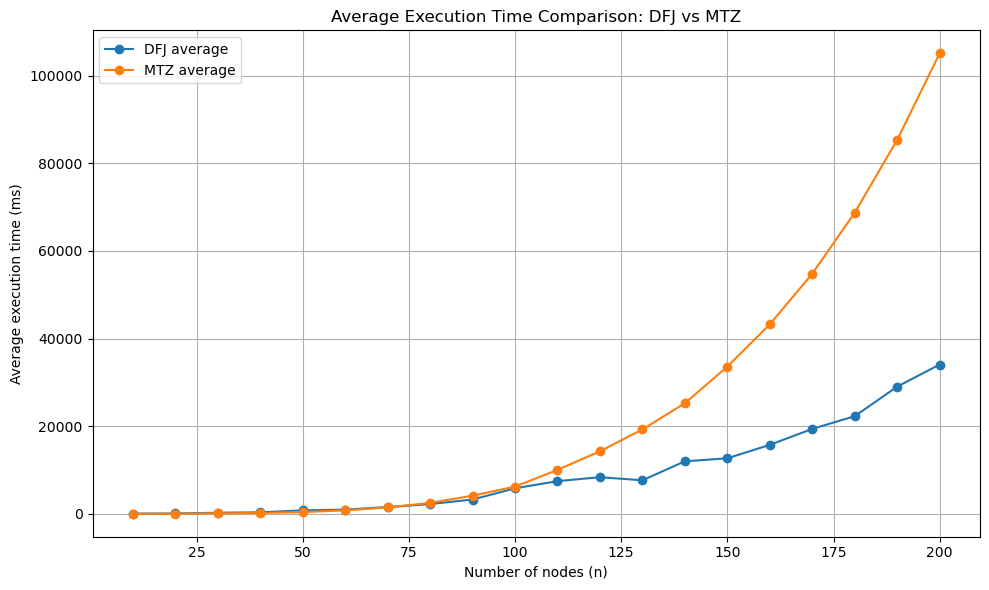

In [3]:
data_dir = Path("results")

json_data = {}

for file in data_dir.rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        json_data[str(file)] = json.load(f)

plot_execution_time(json_data)

In [4]:
import matplotlib.pyplot as plt

def plot_execution_time_boxplot(json_data, value):
    dfj_times, mtz_times = {}, {}

    # collect all execution times per n
    for full_run in json_data.values():
        for execution in full_run:
            n = execution["n"]

            if n not in dfj_times:
                dfj_times[n] = []
                mtz_times[n] = []

            dfj_times[n].append(execution["dfj_time_ms"])
            mtz_times[n].append(execution["mtz_time_ms"])

    x_values = sorted(dfj_times.keys())

    dfj_data = [dfj_times[n] for n in x_values]
    mtz_data = [mtz_times[n] for n in x_values]

    plt.figure(figsize=(12, 6))

    # create shifted positions so DFJ and MTZ are side by side
    positions_dfj = [i - 0.2 for i in range(len(x_values))]
    positions_mtz = [i + 0.2 for i in range(len(x_values))]
    if value == "dfj":
        plt.boxplot(
            dfj_data,
            positions=positions_dfj,
            widths=0.35,
            patch_artist=True,
            boxprops=dict(facecolor="lightblue"),
            medianprops=dict(color="black"),
        )
    elif value == "mtz":
        plt.boxplot(
            mtz_data,
            positions=positions_mtz,
            widths=0.35,
            patch_artist=True,
            boxprops=dict(facecolor="lightgreen"),
            medianprops=dict(color="black"),
        )

    plt.xticks(range(len(x_values)), x_values)

    plt.xlabel("Number of nodes (n)")
    plt.ylabel("Execution time (ms)")
    plt.title("Execution Time Distribution Comparison: DFJ vs MTZ")
    plt.grid(True, axis="y")
    plt.tight_layout()

    # manual legend
    if value == "dfj":
        plt.plot([], c="lightblue", label="DFJ")
    elif value == "mtz":
        plt.plot([], c="lightgreen", label="MTZ")
    plt.legend()

    plt.show()

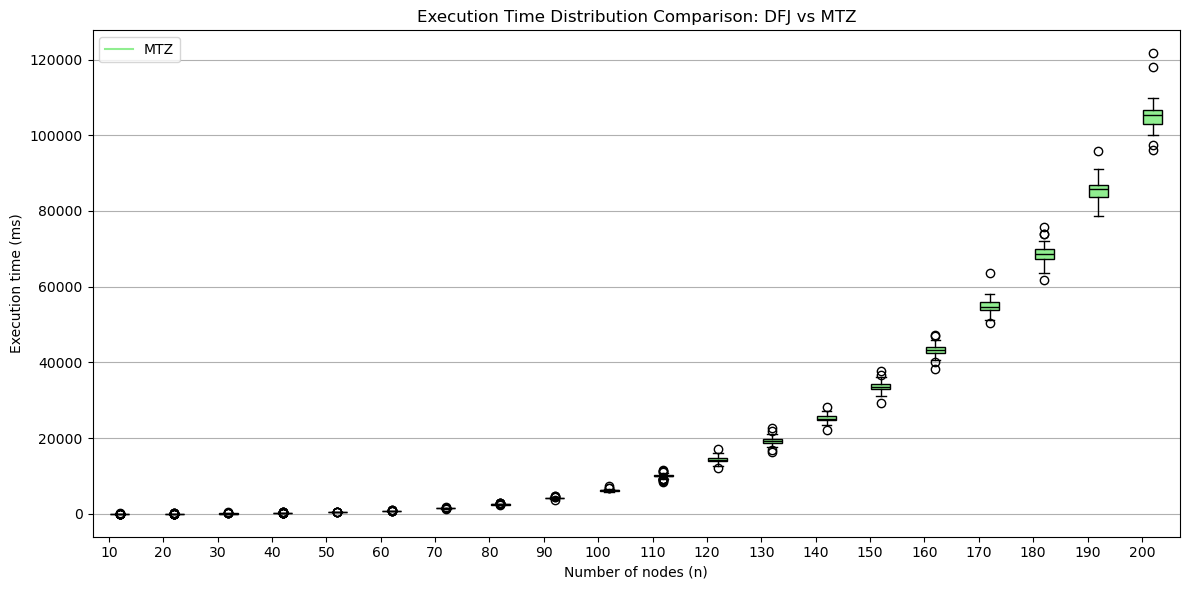

In [5]:
plot_execution_time_boxplot(json_data, value="mtz")

In [8]:
import pandas as pd

def create_statistics_df(json_data):
    dfj_times, mtz_times = {}, {}

    # collect execution times per n
    for full_run in json_data.values():
        for execution in full_run:
            n = execution["n"]

            if n not in dfj_times:
                dfj_times[n] = []
                mtz_times[n] = []

            dfj_times[n].append(execution["dfj_time_ms"])
            mtz_times[n].append(execution["mtz_time_ms"])

    rows = []

    for n in sorted(dfj_times.keys()):
        for algorithm, values in [
            ("DFJ", dfj_times[n]),
            ("MTZ", mtz_times[n])
        ]:
            avg = pd.Series(values).mean()
            std = pd.Series(values).std()

            # coefficient of variation in percent
            cv = (std / avg) * 100 if avg != 0 else None

            rows.append({
                "n": n,
                "algorithm": algorithm,
                "average_time_ms": round(avg, 2),
                "std_time_ms": round(std, 2),
                "coefficient_of_variation_percent": round(cv, 2),
                # "number_of_runs": len(values)
            })

    stats_df = pd.DataFrame(rows)

    return stats_df

stats_df = create_statistics_df(json_data)
stats_df

,n,algorithm,average_time_ms,std_time_ms,coefficient_of_variation_percent
0,10,DFJ,20.03,32.96,164.55
1,10,MTZ,5.99,10.12,168.96
2,20,DFJ,58.49,115.30,197.13
3,20,MTZ,18.88,15.45,81.81
4,30,DFJ,230.83,324.29,140.49
5,30,MTZ,90.89,63.38,69.74
6,40,DFJ,325.27,441.64,135.77
7,40,MTZ,170.77,54.89,32.14
8,50,DFJ,767.23,1241.80,161.86
9,50,MTZ,367.89,11.14,3.03


In [11]:
import pandas as pd

def create_statistics_df_memory(json_data):
    dfj_times, mtz_times = {}, {}

    # collect execution times per n
    for full_run in json_data.values():
        for execution in full_run:
            n = execution["n"]

            if n not in dfj_times:
                dfj_times[n] = []
                mtz_times[n] = []

            dfj_times[n].append(execution["dfj_size_bytes_1"])
            mtz_times[n].append(execution["mtz_size_bytes_1"])

    rows = []

    for n in sorted(dfj_times.keys()):
        for algorithm, values in [
            ("DFJ", dfj_times[n]),
            ("MTZ", mtz_times[n])
        ]:
            avg = pd.Series(values).mean()
            std = pd.Series(values).std()

            # coefficient of variation in percent
            cv = (std / avg) * 100 if avg != 0 else None

            rows.append({
                "n": n,
                "algorithm": algorithm,
                "average_memory_kb": round(avg/1000, 2),
                "std_memory_kb": round(std/1000, 2),
                "coefficient_of_variation_percent": round(cv, 2),
                # "number_of_runs": len(values)
            })

    stats_df = pd.DataFrame(rows)

    return stats_df

stats_df_memory = create_statistics_df_memory(json_data)
stats_df_memory

,n,algorithm,average_memory_kb,std_memory_kb,coefficient_of_variation_percent
0,10,DFJ,46.04,1.32,2.87
1,10,MTZ,99.24,0.06,0.06
2,20,DFJ,261.55,9.86,3.77
3,20,MTZ,1319.38,0.03,0.00
4,30,DFJ,783.08,30.64,3.91
5,30,MTZ,6494.74,0.02,0.00
6,40,DFJ,1708.12,58.92,3.45
7,40,MTZ,20377.30,0.01,0.00
8,50,DFJ,3229.91,114.06,3.53
9,50,MTZ,49639.06,0.01,0.00
